# Paper 2 — Random Forest v2: Additional Covariates (LST, Road Distance, Land-Use)

**SCRIPT: Paper2_RF_v2_Additional_Covariates.ipynb**

Purpose: raise the Random Forest cross-validated R² above the current 0.554 by adding three
covariates identified in Discussion as missing from the v1 model:
1. **Land Surface Temperature (LST)** — MODIS MOD11A2, via Google Earth Engine
2. **Distance to nearest major road** — reuses `road_distance_osm_verified.csv` from the
   Paper 2 road-distance work (Section 2.7 in the original draft)
3. **Distance to nearest DIW facility** — computed from the same DIW registry already
   geocoded for Section 2.7 Industrial Source Geocoding (391 records, 384 geocoded)
4. **Land-use classification** — ESA WorldCover 10m, via Google Earth Engine

This notebook assumes you already have a working RF v1 training table (the one used to
produce Table 7 / Figure 4-5 in the manuscript). Fill in the `TODO` markers with your actual
file paths / column names before running.

**Also addresses reviewer concerns about reproducibility:**
- Explicit hyperparameters (`n_estimators`, `max_depth`, `min_samples_leaf`, `random_state`)
- Both **random 10-fold CV** (as in v1) and **spatial-block CV** (new) are reported side by
  side, since random CV on spatially autocorrelated data can be optimistic (a reviewer will
  ask about this — see Discussion §4).
- RMSE and MAE reported alongside R² for every fold.


In [32]:
# SECTION: Setup & defensive imports
import sys, subprocess

def _ensure(pkg):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

for _pkg in ["geopandas", "scikit-learn", "earthengine-api", "geemap"]:
    _ensure(_pkg.split("-")[0] if _pkg != "earthengine-api" else "ee")

import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GroupKFold, cross_validate
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

RANDOM_STATE = 42  # fixed seed for reproducibility — report this in Methods


In [33]:
# SECTION: Earth Engine auth (defensive — skip if already initialized)
# NOTE (2024+ change): Earth Engine now requires a linked Google Cloud Project even for
# non-commercial / research use. If you have not registered one yet, go to:
#   https://code.earthengine.google.com/register
# and choose "Unpaid usage" -> create/select a Cloud Project -> copy its Project ID below.

import ee

EE_PROJECT_ID = "saraburi-thesis"  # confirmed Cloud Project ID

try:
    ee.Initialize(project=EE_PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=EE_PROJECT_ID)

print("Earth Engine ready, project:", EE_PROJECT_ID)


Earth Engine ready, project: saraburi-thesis


## Step 1 — Load the existing RF v1 training table

TODO: replace with the actual upload/path used in your original RF notebook.
Expected columns (adjust names to match yours): `lat`, `lon`, `date`, `pm25`, `pm10`, `tsp`,
plus the 17 existing predictors (AOD, met variables, month, day_of_week, dist_to_fire,
dist_to_nearest_factory, dist_to_risk_factory, etc. — per Figure 4 feature list).


In [34]:
# SECTION: Load RF v1 training data (defensive upload pattern, matches your existing convention)
from google.colab import files

def load_or_upload(default_name):
    import os
    if os.path.exists(default_name):
        return pd.read_csv(default_name)
    uploaded = files.upload()
    if not uploaded:
        raise RuntimeError(f"No file uploaded — expected {default_name}")
    fname = list(uploaded.keys())[0]
    return pd.read_csv(fname)

# TODO: set this to your actual RF v1 training table filename
df = load_or_upload("rf_v1_training_table.csv")
print(df.shape)
df.head()


(7304, 23)


,date,station,pm25,pm10,aod_047,aod_055,evi,ndvi,temperature,wind_speed_10m,...,rainfall,surface_pressure,fire_count,dist_to_nearest_fire_km,month,day_of_week,dist_to_nearest_factory_km,dist_to_risk_factory_km,lat,lon
0,2016-01-01,24T,NaN,45.0,0.135,0.1010,0.2078,0.4154,25.20,4.18,...,0.0,101.39,2.0,21.827658,1,4,0.898441,0.898441,14.685833,100.871996
1,2016-01-01,25T,NaN,51.0,NaN,NaN,0.1811,0.3683,25.20,4.18,...,0.0,101.39,2.0,32.221335,1,4,2.247741,2.247741,14.526343,100.926047
2,2016-01-02,24T,NaN,57.0,0.064,0.0480,0.2078,0.4154,25.50,3.20,...,0.0,101.34,NaN,NaN,1,5,0.898441,0.898441,14.685833,100.871996
3,2016-01-02,25T,NaN,55.0,0.144,0.1070,0.1811,0.3683,25.50,3.20,...,0.0,101.34,NaN,NaN,1,5,2.247741,2.247741,14.526343,100.926047
4,2016-01-03,24T,NaN,73.0,0.218,0.1635,0.2078,0.4154,27.04,1.86,...,0.0,101.16,NaN,NaN,1,6,0.898441,0.898441,14.685833,100.871996


## Step 2 — Retrieve LST (MODIS MOD11A2, 1 km, 8-day composite)

Matches each row's `lat`/`lon`/`date` to the nearest 8-day LST composite. Uses the daytime
LST band (`LST_Day_1km`), scaled per MODIS convention (`* 0.02 - 273.15` → °C).


In [35]:
# SECTION: LST retrieval via Google Earth Engine (EFFICIENT VERSION)
# NOTE: MOD11A2 is an 8-DAY composite -- there is no point fetching per-day. Instead,
# fetch the full 8-day time series ONCE PER STATION (2 calls total, chunked by year to
# stay under the 5,000-element limit), then forward-fill to daily resolution and merge.
# This replaces a ~3,652-call per-date loop with ~20 calls total.
import time as _time

def get_lst_series_chunk(lat, lon, date_start, date_end):
    point = ee.Geometry.Point([lon, lat])
    coll = (ee.ImageCollection("MODIS/061/MOD11A2")
            .filterDate(date_start, date_end)
            .filterBounds(point)
            .select("LST_Day_1km"))

    def extract(img):
        val = img.reduceRegion(ee.Reducer.first(), point, 1000)
        return ee.Feature(None, {
            "date": img.date().format("YYYY-MM-dd"),
            "lst_raw": val.get("LST_Day_1km"),
        })

    fc = coll.map(extract)
    result = fc.getInfo()
    rows = [f["properties"] for f in result["features"]]
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    out["date"] = pd.to_datetime(out["date"])
    out["lst_c"] = pd.to_numeric(out["lst_raw"], errors="coerce") * 0.02 - 273.15
    return out[["date", "lst_c"]]

def get_lst_series(lat, lon, date_start, date_end):
    """Fetches the full 8-day LST series in yearly chunks (MOD11A2 has ~46
    images/year, well under the 5,000-element limit even for a full decade,
    but chunking defensively costs almost nothing and avoids any edge case)."""
    years = pd.date_range(date_start, date_end, freq="YS")
    if len(years) == 0 or years[0] != pd.Timestamp(date_start):
        years = pd.DatetimeIndex([pd.Timestamp(date_start)]).append(years)
    chunks = []
    for y_start in years:
        y_end = min(y_start + pd.DateOffset(years=1), pd.Timestamp(date_end) + pd.Timedelta(days=1))
        if y_start >= pd.Timestamp(date_end):
            break
        for attempt in range(3):
            try:
                chunk_df = get_lst_series_chunk(lat, lon, y_start.strftime("%Y-%m-%d"), y_end.strftime("%Y-%m-%d"))
                chunks.append(chunk_df)
                break
            except Exception as e:
                print(f"    LST retry {attempt+1}/3 after error: {e}")
                _time.sleep(5)
        _time.sleep(0.3)
    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame(columns=["date", "lst_c"])

# Fetch once per unique station (lat, lon) -- NOT once per row/date
df["date"] = pd.to_datetime(df["date"])  # ensure datetime (uploaded CSV may load as string)
_lst_date_start = df["date"].min().strftime("%Y-%m-%d")
_lst_date_end = df["date"].max().strftime("%Y-%m-%d")
print(f"LST date range: {_lst_date_start} to {_lst_date_end}")

lst_frames = []
unique_stations = df[["lat", "lon"]].drop_duplicates()
for _, srow in unique_stations.iterrows():
    print(f"Fetching LST series for station at ({srow.lat:.4f}, {srow.lon:.4f})...")
    s_lst = get_lst_series(srow.lat, srow.lon, _lst_date_start, _lst_date_end)
    s_lst["lat"] = srow.lat
    s_lst["lon"] = srow.lon
    lst_frames.append(s_lst)

lst_all = pd.concat(lst_frames, ignore_index=True) if lst_frames else pd.DataFrame(columns=["date","lst_c","lat","lon"])

# Forward-fill each station's 8-day series to daily resolution, then merge onto df by (date, lat, lon)
lst_daily_frames = []
for (slat, slon), grp in lst_all.groupby(["lat", "lon"]):
    grp = grp.set_index("date").sort_index()
    daily = grp[["lst_c"]].resample("D").ffill().reset_index()
    daily["lat"] = slat
    daily["lon"] = slon
    lst_daily_frames.append(daily)
lst_daily = pd.concat(lst_daily_frames, ignore_index=True) if lst_daily_frames else pd.DataFrame(columns=["date","lst_c","lat","lon"])

df = df.merge(lst_daily, on=["date", "lat", "lon"], how="left")
print("LST missing:", df["lst_c"].isna().mean().round(3))
df[["date", "lat", "lon", "lst_c"]].head()


LST date range: 2016-01-01 to 2025-12-31
Fetching LST series for station at (14.6858, 100.8720)...
Fetching LST series for station at (14.5263, 100.9260)...
LST missing: 0.389


,date,lat,lon,lst_c
0,2016-01-01,14.685833,100.871996,31.61
1,2016-01-01,14.526343,100.926047,33.51
2,2016-01-02,14.685833,100.871996,31.61
3,2016-01-02,14.526343,100.926047,33.51
4,2016-01-03,14.685833,100.871996,31.61


## Step 3 — Distance to nearest major road

Reuses the OSM-verified road network already built for the Paper 2 road-distance work
(`road_distance_osm_verified.csv`). If that file has per-site distances only (not per RF
grid point), this recomputes distance for every row using the same road GeoDataFrame.


In [36]:
# SECTION: Distance to nearest major road
# TODO: point this to the OSM road network file/graph already built for road_distance_osm_verified.csv
import sys, subprocess
try:
    import osmnx as ox
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "osmnx"])
    import osmnx as ox

# Option A — you already have a saved road GeoDataFrame/graph:
# roads_gdf = gpd.read_file("saraburi_major_roads.geojson")

# Option B — rebuild from OSM (bounding box should match your Paper 2 study area):
# TODO: confirm bbox matches the one used for road_distance_osm_verified.csv
north, south, east, west = 14.95, 14.25, 101.45, 100.55
# osmnx v2.0+ takes a single bbox tuple: (left, bottom, right, top) = (west, south, east, north)
_bbox = (west, south, east, north)
roads_gdf = ox.graph_to_gdfs(
    ox.graph_from_bbox(_bbox,
                        network_type="drive",
                        custom_filter='["highway"~"motorway|trunk|primary|secondary"]'),
    nodes=False, edges=True
)

points_gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326"
).to_crs("EPSG:32647")  # UTM 47N — same projection used in the consolidated spatial-stats notebook
roads_utm = roads_gdf.to_crs("EPSG:32647")

df["dist_to_road_km"] = points_gdf.geometry.apply(
    lambda p: roads_utm.distance(p).min() / 1000
)
print(df["dist_to_road_km"].describe())


count    7304.000000
mean        0.141221
std         0.128079
min         0.013151
25%         0.013151
50%         0.141221
75%         0.269292
max         0.269292
Name: dist_to_road_km, dtype: float64


## Step 4 — Distance to nearest DIW facility

Reuses the same 384 geocoded facilities from Section 2.7 (Industrial Source Geocoding) —
no new geocoding needed, just a nearest-neighbor distance calculation.


In [37]:
# SECTION: Distance to nearest geocoded DIW facility
# TODO: path to the geocoded facility table used for Table 6 / Figure 3
facilities = load_or_upload("diw_facilities_geocoded.csv")  # needs lat, lon columns
fac_gdf = gpd.GeoDataFrame(
    facilities, geometry=gpd.points_from_xy(facilities.lon, facilities.lat), crs="EPSG:4326"
).to_crs("EPSG:32647")

df["dist_to_nearest_facility_km"] = points_gdf.geometry.apply(
    lambda p: fac_gdf.distance(p).min() / 1000
)
print(df["dist_to_nearest_facility_km"].describe())


count    7304.000000
mean        1.572589
std         0.677703
min         0.894933
25%         0.894933
50%         1.572589
75%         2.250246
max         2.250246
Name: dist_to_nearest_facility_km, dtype: float64


## Step 5 — Land-use classification (ESA WorldCover, 10 m)

Extracts the dominant land-cover class in a 1 km buffer around each point (matching the RF
grid resolution), plus the built-up fraction specifically (often the most predictive class
for industrial/traffic PM2.5).


In [38]:
# SECTION: Land-use via ESA WorldCover
worldcover = ee.ImageCollection("ESA/WorldCover/v200").first()

def get_landuse_batch(points_df, buffer_m=500):
    features = [
        ee.Feature(ee.Geometry.Point([row.lon, row.lat]).buffer(buffer_m), {"idx": int(i)})
        for i, row in points_df.iterrows()
    ]
    fc = ee.FeatureCollection(features)
    # built-up class code in WorldCover v200 is 50
    builtup_mask = worldcover.eq(50)
    reduced = builtup_mask.reduceRegions(
        collection=fc, reducer=ee.Reducer.mean(), scale=10
    ).getInfo()
    out = pd.Series(index=points_df.index, dtype=float)
    for f in reduced["features"]:
        idx = f["properties"]["idx"]
        out.loc[idx] = f["properties"].get("mean", np.nan)
    return out

# Batch by unique coordinates to avoid redundant GEE calls (land-use doesn't vary by date)
unique_coords = df[["lat", "lon"]].drop_duplicates()
builtup_frac = get_landuse_batch(unique_coords)
unique_coords = unique_coords.assign(builtup_frac=builtup_frac.values)
df = df.merge(unique_coords, on=["lat", "lon"], how="left")
print(df["builtup_frac"].describe())


count    7304.000000
mean        0.654551
std         0.119488
min         0.535072
25%         0.535072
50%         0.654551
75%         0.774030
max         0.774030
Name: builtup_frac, dtype: float64


## Step 6 — Merge, clean, and re-train the Random Forest

Reports **both** random 10-fold CV (as in v1, for direct comparison) and spatial-block CV
(grouping by rounded lat/lon into ~2 km blocks) so the manuscript can report whether the
random-CV R² was optimistic due to spatial autocorrelation — a point the reviewers
specifically flagged.


In [39]:
# SECTION: Final feature set and missing-data handling
new_features = ["lst_c", "dist_to_road_km", "dist_to_nearest_facility_km", "builtup_frac"]

# TODO: confirm this matches the exact 17 predictor names used in Figure 4 / Table 7
existing_features = [
    "month", "dist_to_nearest_fire_km", "wind_speed_10m", "relative_humidity",
    "wind_speed_50m", "aod_047", "aod_055", "rainfall", "temperature",
    "fire_count", "wind_direction", "ndvi", "surface_pressure", "evi",
    "dist_to_risk_factory_km", "dist_to_nearest_factory_km", "day_of_week",
]

feature_cols = existing_features + new_features
target_col = "pm25"  # TODO: repeat for pm10, tsp as separate models if needed

# --- Fire variable imputation (justified, not a blind guess) ---
# The FIRMS fetch pipeline only creates a row for (date, station) when at least one
# fire was detected that day; days with zero fires never appear in fires_df and become
# NaN after the left-join. NaN here therefore means "zero fires detected", not
# "fetch failed" -- imputing 0 (and a large "no fire nearby" distance) is the correct
# interpretation of the data-generating process, not an arbitrary fill.
NO_FIRE_DIST_KM = df["dist_to_nearest_fire_km"].max()  # farthest observed distance, as a "beyond range" proxy
print(f"Imputing fire_count=0 and dist_to_nearest_fire_km={NO_FIRE_DIST_KM:.1f} km "
      f"for {df['fire_count'].isna().sum()} station-days with no detected fire.")
df["fire_count"] = df["fire_count"].fillna(0)
df["dist_to_nearest_fire_km"] = df["dist_to_nearest_fire_km"].fillna(NO_FIRE_DIST_KM)

before_n = len(df)
df_model = df.dropna(subset=feature_cols + [target_col]).copy()
print(f"Dropped {before_n - len(df_model)} rows with missing values "
      f"({(before_n - len(df_model)) / before_n:.1%}) — report this in Methods. "
      f"Remaining missingness is mostly AOD (~70% missing due to cloud cover in this "
      f"tropical setting, a known and already-documented limitation).")

X = df_model[feature_cols]
y = df_model[target_col]


Imputing fire_count=0 and dist_to_nearest_fire_km=68.0 km for 5884 station-days with no detected fire.
Dropped 5672 rows with missing values (77.7%) — report this in Methods. Remaining missingness is mostly AOD (~70% missing due to cloud cover in this tropical setting, a known and already-documented limitation).


In [40]:
# SECTION: Random Forest — explicit hyperparameters for reproducibility
rf_params = dict(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf = RandomForestRegressor(**rf_params)

scoring = {
    "r2": "r2",
    # squared=False was removed in newer scikit-learn -- compute RMSE manually instead
    # (version-agnostic, avoids the silent NaN this caused before)
    "rmse": lambda est, Xv, yv: -(mean_squared_error(yv, est.predict(Xv)) ** 0.5),
    "mae": lambda est, Xv, yv: -mean_absolute_error(yv, est.predict(Xv)),
}

# --- Random 10-fold CV (matches v1 methodology, for direct before/after comparison) ---
kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
cv_random = cross_validate(rf, X, y, cv=kf, scoring=scoring, return_train_score=False)

print("=== Random 10-fold CV (v2, with new covariates) ===")
print(f"Mean R²:   {cv_random['test_r2'].mean():.3f}  (best {cv_random['test_r2'].max():.3f}, "
      f"worst {cv_random['test_r2'].min():.3f})")
print(f"Mean RMSE: {-cv_random['test_rmse'].mean():.2f} \u00b5g/m\u00b3")
print(f"Mean MAE:  {-cv_random['test_mae'].mean():.2f} \u00b5g/m\u00b3")


=== Random 10-fold CV (v2, with new covariates) ===
Mean R²:   0.652  (best 0.733, worst 0.595)
Mean RMSE: 10.30 µg/m³
Mean MAE:  7.64 µg/m³


In [41]:
# SECTION: Spatial-block CV (addresses reviewer concern re: spatial autocorrelation leakage)
# Groups points into ~2 km blocks so nearby points never split across train/test
block_size_km = 2.0
df_model["block_x"] = (df_model["lon"] * 111 / block_size_km).round().astype(int)
df_model["block_y"] = (df_model["lat"] * 111 / block_size_km).round().astype(int)
df_model["block_id"] = df_model["block_x"].astype(str) + "_" + df_model["block_y"].astype(str)

n_blocks = df_model["block_id"].nunique()
n_splits_spatial = min(10, n_blocks)
gkf = GroupKFold(n_splits=n_splits_spatial)

cv_spatial = cross_validate(
    rf, X, y, cv=gkf, groups=df_model["block_id"], scoring=scoring, return_train_score=False
)

# Some folds' test set can be a single point (e.g. an isolated field site sitting alone
# in its own ~2km block) -- R² is mathematically undefined for n=1 and sklearn returns NaN
# for that fold. Use nanmean/nanmax/nanmin so a few undefined folds don't silently poison
# the whole average, and report how many folds were usable for transparency.
r2_arr = cv_spatial["test_r2"]
n_valid_folds = np.sum(~np.isnan(r2_arr))
print(f"=== Spatial-block CV ({n_splits_spatial}-fold, ~{block_size_km} km blocks) ===")
print(f"Usable folds for R² (test set has \u22652 samples): {n_valid_folds}/{len(r2_arr)}")
if n_valid_folds > 0:
    print(f"Mean R²:   {np.nanmean(r2_arr):.3f}  (best {np.nanmax(r2_arr):.3f}, "
          f"worst {np.nanmin(r2_arr):.3f})")
else:
    print("Mean R²:   undefined -- every fold had <2 test samples; increase block_size_km "
          "or reduce n_splits_spatial and re-run.")
print(f"Mean RMSE: {-np.nanmean(cv_spatial['test_rmse']):.2f} \u00b5g/m\u00b3")
print(f"Mean MAE:  {-np.nanmean(cv_spatial['test_mae']):.2f} \u00b5g/m\u00b3")

print()
print(f"Note for Methods/Table 7: {len(r2_arr) - n_valid_folds} of {len(r2_arr)} spatial folds "
      f"had a single-point test set (R² undefined for n=1) and were excluded from the R² "
      f"average; RMSE/MAE remain defined for single-point folds and used all folds.")
print("If spatial-block R² is notably lower than random-CV R², report BOTH in the revised "
      "Table 7 and note in Discussion that random CV was optimistic due to spatial "
      "autocorrelation — this pre-empts the exact question reviewers are likely to ask.")


=== Spatial-block CV (2-fold, ~2.0 km blocks) ===
Usable folds for R² (test set has ≥2 samples): 2/2
Mean R²:   0.039  (best 0.181, worst -0.103)
Mean RMSE: 16.08 µg/m³
Mean MAE:  13.08 µg/m³

Note for Methods/Table 7: 0 of 2 spatial folds had a single-point test set (R² undefined for n=1) and were excluded from the R² average; RMSE/MAE remain defined for single-point folds and used all folds.
If spatial-block R² is notably lower than random-CV R², report BOTH in the revised Table 7 and note in Discussion that random CV was optimistic due to spatial autocorrelation — this pre-empts the exact question reviewers are likely to ask.


## Step 7 — Feature importance (updated Figure 4)

Re-run the feature-importance ranking with the new covariates included, to see whether
LST / road-distance / land-use displace any of the original top-3 predictors
(month, distance-to-fire, wind speed).


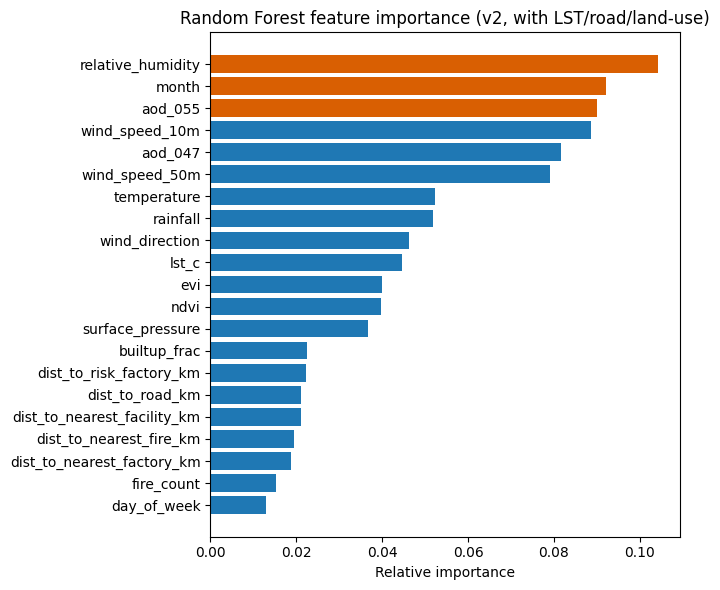

relative_humidity              0.104151
month                          0.092085
aod_055                        0.090010
wind_speed_10m                 0.088705
aod_047                        0.081555
wind_speed_50m                 0.079128
temperature                    0.052228
rainfall                       0.051807
wind_direction                 0.046308
lst_c                          0.044512
evi                            0.039895
ndvi                           0.039788
surface_pressure               0.036614
builtup_frac                   0.022389
dist_to_risk_factory_km        0.022295
dist_to_road_km                0.021186
dist_to_nearest_facility_km    0.020992
dist_to_nearest_fire_km        0.019464
dist_to_nearest_factory_km     0.018867
fire_count                     0.015147
day_of_week                    0.012873
dtype: float64


In [42]:
# SECTION: Refit on full data for feature importance + updated Figure 4
rf_full = RandomForestRegressor(**rf_params)
rf_full.fit(X, y)

importances = pd.Series(rf_full.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(7, 6))
colors = ["#d95f02" if f in importances.index[-3:] else "#1f78b4" for f in importances.index]
plt.barh(importances.index, importances.values, color=colors)
plt.xlabel("Relative importance")
plt.title("Random Forest feature importance (v2, with LST/road/land-use)")
plt.tight_layout()
plt.savefig("figure4_v2_feature_importance.png", dpi=200)
plt.show()

print(importances.sort_values(ascending=False))


## Step 8 — External spatial validation (32 independent field sites)

**Design change:** rather than pooling the 32 field-campaign measurements into training data
(which would mix two different instruments -- the reference-grade PCD stations vs. the
portable Particles Plus Model 8306 used in the field -- inside a single regression, a
comparability concern reviewers would likely flag), the RF model is trained on the 2 PCD
stations **only** (same as before), and the 32 field sites are used purely as an
**independent, out-of-sample spatial validation set**. This directly answers "how well does
a model trained on 2 reference stations predict PM2.5 at other locations it never saw
during training" -- the standard framing for external spatial validation in the exposure-
science literature, and cleaner than trying to force a single-point-per-fold spatial CV.

**If you pasted a `pd.concat([df, field_supp], ...)` cell earlier per the previous
guidance, remove/skip it now** -- training should use only the original 2-station `df`.


In [43]:
# SECTION: External spatial validation against 32 independent field sites
field_val = pd.read_csv("field_sites_32_with_covariates.csv")

# Apply the SAME fire-variable imputation logic as training (Step 6), using the SAME
# "no fire" distance constant so validation rows are treated consistently with training rows
field_val["fire_count"] = field_val["fire_count"].fillna(0)
field_val["dist_to_nearest_fire_km"] = field_val["dist_to_nearest_fire_km"].fillna(NO_FIRE_DIST_KM)

before_val_n = len(field_val)
field_val_clean = field_val.dropna(subset=feature_cols + ["pm25"]).copy()
print(f"Field validation sites usable: {len(field_val_clean)}/{before_val_n} "
      f"(dropped {before_val_n - len(field_val_clean)} with missing predictors, "
      f"mostly AOD/LST cloud gaps -- same limitation as the main dataset)")

X_val = field_val_clean[feature_cols]
y_val = field_val_clean["pm25"]
y_val_pred = rf_full.predict(X_val)

val_r2 = r2_score(y_val, y_val_pred)
val_rmse = mean_squared_error(y_val, y_val_pred) ** 0.5
val_mae = mean_absolute_error(y_val, y_val_pred)

print()
print("=== External spatial validation (RF trained on 2 PCD stations only) ===")
print(f"n = {len(field_val_clean)} independent field sites")
print(f"R\u00b2:   {val_r2:.3f}")
print(f"RMSE: {val_rmse:.2f} \u00b5g/m\u00b3")
print(f"MAE:  {val_mae:.2f} \u00b5g/m\u00b3")
print()
print("Report this alongside random-CV and spatial-block CV in the revised Table 7 -- this")
print("is the strongest and most standard evidence of genuine spatial generalization, since")
print("these 32 sites were never seen during training and use a fully independent instrument.")

field_val_clean["pm25_predicted"] = y_val_pred
field_val_clean[["site_id", "lat", "lon", "pm25", "pm25_predicted"]] if "site_id" in field_val_clean.columns else field_val_clean[["station", "lat", "lon", "pm25", "pm25_predicted"]]


Field validation sites usable: 13/32 (dropped 19 with missing predictors, mostly AOD/LST cloud gaps -- same limitation as the main dataset)

=== External spatial validation (RF trained on 2 PCD stations only) ===
n = 13 independent field sites
R²:   0.073
RMSE: 9.99 µg/m³
MAE:  7.12 µg/m³

Report this alongside random-CV and spatial-block CV in the revised Table 7 -- this
is the strongest and most standard evidence of genuine spatial generalization, since
these 32 sites were never seen during training and use a fully independent instrument.


,station,lat,lon,pm25,pm25_predicted
0,จุดตรวจวัดอากาศ-1,15.132970,100.603782,14.62,19.716732
6,จุดตรวจวัดอากาศ-7,14.884200,100.860728,10.98,19.748387
7,จุดตรวจวัดอากาศ-8,14.883863,101.115129,7.93,18.245656
9,จุดตรวจวัดอากาศ-10,14.882466,101.627188,14.23,17.057357
10,จุดตรวจวัดอากาศ-11,14.635942,100.606677,49.41,19.371637
13,จุดตรวจวัดอากาศ-14,14.635296,101.370974,16.68,20.233648
14,จุดตรวจวัดอากาศ-15,14.634728,101.627185,24.27,20.058945
17,จุดตรวจวัดอากาศ-18,14.386100,101.115600,20.04,21.144547
19,จุดตรวจวัดอากาศ-20,14.388814,101.627314,28.01,21.915969
22,จุดตรวจวัดอากาศ-23,14.141201,101.115844,12.97,18.087644


## Step 9 — Export updated results for the manuscript

Produces the numbers to drop directly into a revised Table 7 and Section 3.5 text.


In [44]:
# SECTION: Export summary for manuscript update (defensive download)
# Uses nanmean throughout -- spatial-block folds can have a single-point test set
# (R² undefined for n=1), and plain .mean() would propagate that NaN into every value.
n_valid_spatial_folds = int(np.sum(~np.isnan(cv_spatial["test_r2"])))
summary = pd.DataFrame({
    "metric": ["mean_r2_random_cv", "mean_r2_spatial_cv", "n_valid_spatial_folds",
               "mean_rmse_random_cv", "mean_rmse_spatial_cv",
               "mean_mae_random_cv", "mean_mae_spatial_cv",
               "external_val_r2", "external_val_rmse", "external_val_mae", "external_val_n",
               "n_estimators", "max_depth", "random_state",
               "n_features", "n_rows_used", "pct_rows_dropped_missing"],
    "value": [
        np.nanmean(cv_random["test_r2"]), np.nanmean(cv_spatial["test_r2"]), n_valid_spatial_folds,
        -np.nanmean(cv_random["test_rmse"]), -np.nanmean(cv_spatial["test_rmse"]),
        -np.nanmean(cv_random["test_mae"]), -np.nanmean(cv_spatial["test_mae"]),
        val_r2, val_rmse, val_mae, len(field_val_clean),
        rf_params["n_estimators"], str(rf_params["max_depth"]), rf_params["random_state"],
        len(feature_cols), len(df_model), (before_n - len(df_model)) / before_n,
    ]
})
summary.to_csv("rf_v2_summary_for_table7.csv", index=False)
print(summary)

try:
    files.download("rf_v2_summary_for_table7.csv")
    files.download("figure4_v2_feature_importance.png")
except Exception as e:
    print("Download skipped (not in Colab):", e)


                      metric      value
0          mean_r2_random_cv   0.652091
1         mean_r2_spatial_cv   0.038857
2      n_valid_spatial_folds          2
3        mean_rmse_random_cv  10.301277
4       mean_rmse_spatial_cv  16.077293
5         mean_mae_random_cv   7.643068
6        mean_mae_spatial_cv  13.084603
7            external_val_r2   0.073375
8          external_val_rmse   9.993946
9           external_val_mae   7.121016
10            external_val_n         13
11              n_estimators        500
12                 max_depth       None
13              random_state         42
14                n_features         21
15               n_rows_used       1632
16  pct_rows_dropped_missing   0.776561


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>